# **Sentiment Analysis using NLP Pipeline & ML Models**


In [1]:
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

import nltk
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [7]:
# LOAD DATASET
df=pd.read_csv('/content/test.csv',encoding='ISO-8859-1')
df.head()


,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


In [8]:
print("Shape:", df.shape)

Shape: (4815, 9)


In [9]:
#Data Understanding
print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:
['textID', 'text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']


In [10]:
# Keep only the required columns
df = df[["text", "sentiment"]].copy()

print("Missing values:")
print(df.isnull().sum())

df.dropna(inplace=True)
df["text"] = df["text"].astype(str)

print("\nDataset shape after cleaning:", df.shape)
print("\nClass distribution:")
print(df["sentiment"].value_counts())


Missing values:
text         1281
sentiment    1281
dtype: int64

Dataset shape after cleaning: (3534, 2)

Class distribution:
sentiment
neutral     1430
positive    1103
negative    1001
Name: count, dtype: int64


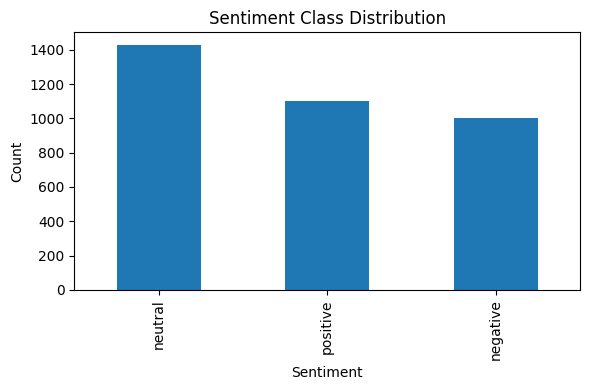

In [11]:
ax = df["sentiment"].value_counts().plot(kind="bar", figsize=(6,4), title="Sentiment Class Distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [12]:
print("Sample texts:\n")
for _, row in df.sample(5, random_state=42).iterrows():
    print("Sentiment:", row["sentiment"])
    print("Text     :", row["text"][:300])
    print("-" * 100)

Sample texts:

Sentiment: positive
Text     :  Thank you so much phaoloo !!!!
----------------------------------------------------------------------------------------------------
Sentiment: negative
Text     : Midnight ice-cream weather! So **** bored
----------------------------------------------------------------------------------------------------
Sentiment: positive
Text     : Ohh i forgot to tell you last night that when i was a alton towers i touched a shark  it was amazing !!!! it was nt a massive one tho
----------------------------------------------------------------------------------------------------
Sentiment: neutral
Text     : i am the only arabic girl who`s online  every one is  a sleep ..
----------------------------------------------------------------------------------------------------
Sentiment: neutral
Text     : starting the video editing of the first spanking movie we did with Mina ... it will be added to the next update
-------------------------------------------

NLP PREPROCESSING


In [13]:
STOP_WORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)   # remove URLs
    text = re.sub(r"@\w+", " ", text)                       # remove mentions
    text = re.sub(r"#", " ", text)                           # keep hashtag words, remove only #
    text = re.sub(r"[^a-zA-Z\s]", " ", text)                # remove punctuation, digits, special chars
    text = re.sub(r"\s+", " ", text).strip()                # remove extra spaces
    return text

def tokenize_and_lemmatize(text):
    tokens = text.split()
    tokens = [word for word in tokens if word not in STOP_WORDS]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return tokens

def preprocess_text(text):
    cleaned = clean_text(text)
    tokens = tokenize_and_lemmatize(cleaned)
    return " ".join(tokens)


In [14]:
df["clean_text"] = df["text"].apply(preprocess_text)
df[["text", "clean_text", "sentiment"]].head()


,text,clean_text,sentiment
0,Last session of the day http://twitpic.com/67ezh,last session day,neutral
1,Shanghai is also really exciting (precisely -...,shanghai also really exciting precisely skyscr...,positive
2,"Recession hit Veronique Branquinho, she has to...",recession hit veronique branquinho quit compan...,negative
3,happy bday!,happy bday,positive
4,http://twitpic.com/4w75p - I like it!!,like,positive


In [15]:
print("Original text:\n")
print(df["text"].iloc[0])

print("\nCleaned text:\n")
print(df["clean_text"].iloc[0])


Original text:

Last session of the day  http://twitpic.com/67ezh

Cleaned text:

last session day


TRAIN TEST SPLIT

In [16]:
X = df["clean_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 2827
Testing samples : 707


FEATURE ENGG

In [17]:
models = {
    "BoW + Logistic Regression": Pipeline([
        ("vectorizer", CountVectorizer(max_features=5000, ngram_range=(1, 2))),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "TF-IDF + Logistic Regression": Pipeline([
        ("vectorizer", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "BoW + Naive Bayes": Pipeline([
        ("vectorizer", CountVectorizer(max_features=5000, ngram_range=(1, 2))),
        ("model", MultinomialNB())
    ]),

    "TF-IDF + Naive Bayes": Pipeline([
        ("vectorizer", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ("model", MultinomialNB())
    ]),

    "TF-IDF + Decision Tree": Pipeline([
        ("vectorizer", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ("model", DecisionTreeClassifier(max_depth=30, random_state=42))
    ]),

    "TF-IDF + Random Forest": Pipeline([
        ("vectorizer", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ("model", RandomForestClassifier(n_estimators=150, random_state=42))
    ])
}


In [18]:
#TRAINING AND EVALUATION
results = []
trained_models = {}

for model_name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results.append({
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1 Score": round(f1, 4)
    })

    trained_models[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,TF-IDF + Random Forest,0.6591,0.6791,0.6591,0.6587
1,TF-IDF + Logistic Regression,0.6365,0.6532,0.6365,0.6363
2,BoW + Logistic Regression,0.6294,0.6423,0.6294,0.6293
3,TF-IDF + Decision Tree,0.6124,0.6782,0.6124,0.5973
4,BoW + Naive Bayes,0.5912,0.6024,0.5912,0.5908
5,TF-IDF + Naive Bayes,0.5799,0.6246,0.5799,0.5675


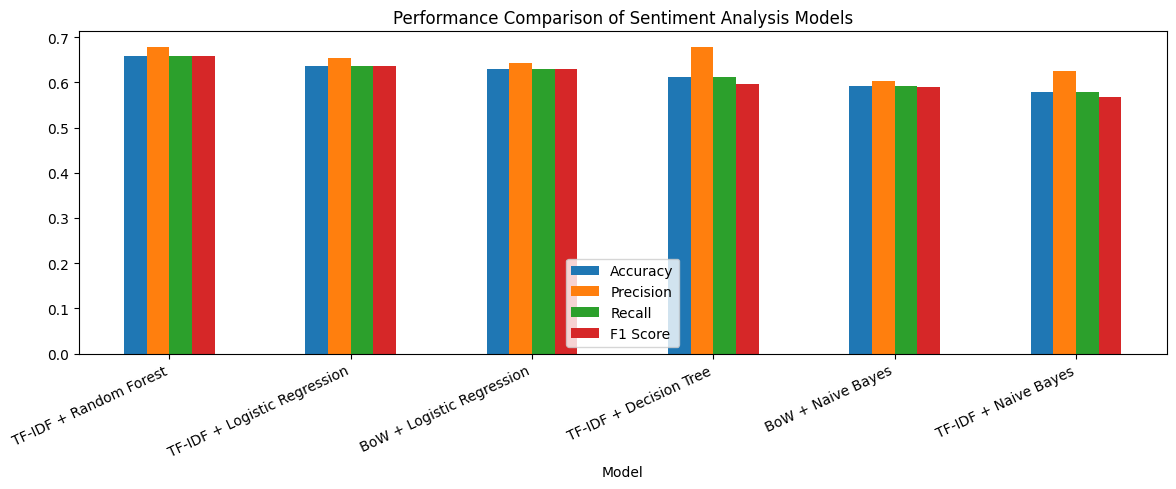

In [19]:
results_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    kind="bar",
    figsize=(12, 5)
)

plt.title("Performance Comparison of Sentiment Analysis Models")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

BEST MODEL ANALYSIS

In [20]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_predictions = best_model.predict(X_test)

print("Best Model:", best_model_name)
print("\nClassification Report:\n")
print(classification_report(y_test, best_predictions, zero_division=0))


Best Model: TF-IDF + Random Forest

Classification Report:

              precision    recall  f1-score   support

    negative       0.74      0.54      0.62       200
     neutral       0.58      0.75      0.65       286
    positive       0.75      0.65      0.70       221

    accuracy                           0.66       707
   macro avg       0.69      0.65      0.66       707
weighted avg       0.68      0.66      0.66       707



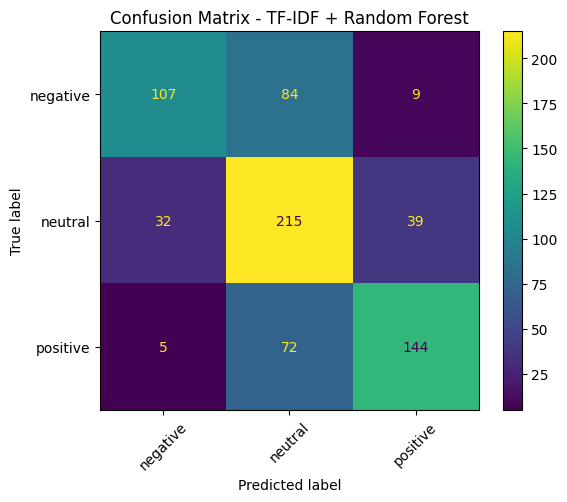

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, best_predictions, ax=ax, xticks_rotation=45)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()


In [22]:
#sample prediction
sample_predictions = pd.DataFrame({
    "Text": X_test.iloc[:10].values,
    "Actual Sentiment": y_test.iloc[:10].values,
    "Predicted Sentiment": best_predictions[:10]
})

sample_predictions


,Text,Actual Sentiment,Predicted Sentiment
0,x yepp like dylan cole better,neutral,positive
1,thank u sweetie wait set sail u next week,positive,positive
2,walker sadly going killumbus show really want ...,neutral,negative
3,spent last hour signing yearbook miss guy,negative,negative
4,think take needle watched horribly gory short ...,negative,neutral
5,would like gaming system,positive,positive
6,shame freud follow implication,negative,negative
7,happy star war day,positive,positive
8,last day tv front w colleague sydney paris london,neutral,neutral
9,good morning went bed feel already morning go ...,positive,positive


# COMPARISON & INSIGHTS
1. **Preprocessing** reduced noise by converting text to lowercase, removing punctuation, removing stopwords, cleaning URLs, and applying lemmatization.
2. **TF-IDF** often performs better than BoW because it gives more weight to informative words and reduces the effect of very common words.
3. **Logistic Regression** is usually a strong baseline for text classification because it handles high-dimensional sparse features well.
4. **Naive Bayes** is fast and effective for NLP tasks, especially on count-based features.
5. **Decision Tree** is easier to interpret, but it often performs worse on sparse text vectors.
6. **Random Forest** is more robust than a single tree, though it may still underperform compared with linear models on text data.
